# Project Phase 1 Analysis
**Team Popcorn – Amritha, Ahana, Keerthana** | *Date: 05/03/2026*

---
**Folder structure expected (notebook lives inside `src/`):**
```
MST_Data/
├── Both_item_task/
│   ├── both_data/          ← *_MST_task_*.csv  +  *_MST_test_*.csv
│   ├── Set6 bins.txt
│   └── SetScC bins.txt
├── item_only/
│   ├── item_only_data/     ← *_MST_task_*.csv  +  *_MST_test_*.csv
│   ├── Set6 bins.txt
│   ├── SetScC bins.txt
│   └── scenes_mapping.txt
└── task_only/
    ├── task_only_data/     ← task*.csv  +  test*.csv
    └── Set6 bins_ob.txt
src/
└── Project_Phase1_Analysis.ipynb   ← YOU ARE HERE
```

## 0. Install Dependencies & Imports

In [157]:
# Uncomment and run once if any package is missing
# !pip install pandas numpy scipy statsmodels pingouin matplotlib seaborn

In [158]:
import os, glob, re, warnings
import numpy as np
import pandas as pd
from scipy import stats
from itertools import combinations

import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

import pingouin as pg

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)

# ── Colour palette (Non=blue, Pre=red, Post=green) ─────────────────────────────
BP_COLORS = {"Non": "#4D9DE0", "Pre": "#E15554", "Post": "#3BB273"}
BP_FILLS  = {"Non": "#AED4F5", "Pre": "#F5AEAE", "Post": "#AEECD0"}
BP_ORDER  = ["Non", "Pre", "Post"]

# ── Base path: point to the MST_Data directory ────────────────────────────────
# Updated to match your actual folder structure
BASE = "/home/user/Desktop/SEMESTER6/BRSM/Project/BRSM-MST/MST_Data (1)"

def data_path(*parts):
    """Build an absolute path relative to BASE."""
    return os.path.join(BASE, *parts)

def style_axes(ax, title="", subtitle="", xlabel="", ylabel=""):
    full_title = f"{title}\n{subtitle}" if subtitle else title
    ax.set_title(full_title, fontweight="bold", fontsize=12)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(axis="y", color="#e8e8e8", linewidth=0.6)
    ax.set_facecolor("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#d0d0d0"); spine.set_linewidth(0.5)

print("Imports OK ✓")
print(f"BASE resolved to: {os.path.abspath(BASE)}")

Imports OK ✓
BASE resolved to: /home/user/Desktop/SEMESTER6/BRSM/Project/BRSM-MST/MST_Data (1)


---
## 1. Bin-File Loaders
Each `.txt` file maps an image number (from the filename, e.g. `060a.jpg` → 60)
to a similarity bin (1–5).

| File | Used for | Experiment |
|---|---|---|
| `Set6 bins.txt` | Objects (≤192) | Both & Item-only |
| `SetScC bins.txt` | Scenes | Both & Item-only |
| `Set6 bins_ob.txt` | Objects (≤384, extended) | Task-only |

In [159]:
def load_bin_file(path):
    """
    Read a two-column tab/space file: image_number  bin_number
    Returns dict {int -> int}.
    """
    bins = {}
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                bins[int(parts[0])] = int(parts[1])
    return bins


def get_bin(image_name, folder, bins_obj, bins_scenes, bins_obj_extended=None):
    """
    Look up the similarity bin for one image.
    image_name : e.g. '060a.jpg'
    folder     : 'Objects' or 'Scenes'
    """
    m = re.search(r'(\d+)', image_name)
    if not m:
        return np.nan
    num = int(m.group(1))
    if folder == "Scenes":
        return bins_scenes.get(num, np.nan)
    else:  # Objects
        if bins_obj_extended and num > 192:
            return bins_obj_extended.get(num, np.nan)
        return bins_obj.get(num, np.nan)


def load_scenes_mapping(path):
    """
    Read scenes_mapping.txt → dict {image_name: correct_key}
    e.g. {'001a.jpg': 'f', '002a.jpg': 'j', ...}
    """
    mapping = {}
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                name = parts[0].replace("\\", "/").split("/")[-1]
                mapping[name] = parts[1]
    return mapping


print("Bin-file loader functions defined ✓")

Bin-file loader functions defined ✓


---
## 2. Statistical Helper Functions

### 2.1 Normality Table — SAP 2.2 / 4 / 7.1

In [160]:
def normality_table(cells_list, caption="Shapiro-Wilk Results"):
    """
    cells_list : list of dicts {'vals': array-like, 'label': str}
    """
    rows = []
    for item in cells_list:
        v   = np.array(item["vals"], dtype=float)
        v   = v[~np.isnan(v)]
        lbl = item["label"]
        if len(v) < 3:
            rows.append({"Condition": lbl, "n": len(v), "W": np.nan, "p": np.nan, "Normal": "Too few"})
            continue
        if np.std(v) == 0:
            rows.append({"Condition": lbl, "n": len(v), "W": np.nan, "p": np.nan, "Normal": "Identical"})
            continue
        W, p = stats.shapiro(v)
        rows.append({"Condition": lbl, "n": len(v),
                     "Normal": "Yes" if p >= 0.05 else "No"})
    df = pd.DataFrame(rows)
    print(f"\n{'─'*55}\n  {caption}\n{'─'*55}")
    display(df.style.hide(axis="index"))
    return df

### 2.2 Descriptive Statistics Table

In [161]:
def summary_table(df, group_vars, dv, caption="Descriptive Statistics"):
    tbl = (df.groupby(group_vars, observed=True)[dv]
             .agg(n="count",
                  Median=lambda x: round(x.median(), 3),
                  Mean=lambda x: round(x.mean(), 3),
                  SD=lambda x: round(x.std(ddof=1), 3),
                  IQR=lambda x: round(x.quantile(0.75) - x.quantile(0.25), 3))
             .reset_index())
    print(f"\n{'─'*55}\n  {caption}\n{'─'*55}")
    display(tbl.style.hide(axis="index"))
    return tbl

### 2.3 Non-Parametric Wrappers

In [162]:
def safe_kruskal(values, groups, label=""):
    df_tmp = pd.DataFrame({"val": values, "grp": groups}).dropna()
    valid  = [g for g, s in df_tmp.groupby("grp") if len(s) > 0]
    if len(valid) < 2:
        print(f"  Skipped – fewer than 2 groups: {label}"); return
    H, p = stats.kruskal(*[df_tmp.loc[df_tmp.grp==g,"val"].values for g in valid])
    print(f"  Kruskal-Wallis  H={H:.4f},  p={p:.4f}  [{label}]")


def safe_pairwise_wilcox(values, groups, label=""):
    df_tmp = pd.DataFrame({"val": values, "grp": groups}).dropna()
    valid  = [g for g, s in df_tmp.groupby("grp") if len(s) > 0]
    if len(valid) < 2:
        print(f"  Skipped – fewer than 2 groups: {label}"); return
    rows = []
    for a, b in combinations(valid, 2):
        U, p = stats.mannwhitneyu(df_tmp.loc[df_tmp.grp==a,"val"].values,
                                   df_tmp.loc[df_tmp.grp==b,"val"].values,
                                   alternative="two-sided")
        rows.append({"Comparison": f"{a} vs {b}", "U": round(U,2), "p_raw": round(p,4)})
    res = pd.DataFrame(rows)
    _, p_adj, _, _ = multipletests(res.p_raw, method="bonferroni")
    res["p_bonferroni"] = p_adj.round(4)
    res["Significant"]  = res.p_bonferroni < 0.05
    print(f"  Bonferroni Pairwise Wilcoxon [{label}]")
    display(res.style.hide(axis="index"))

### 2.4 Aggregate RT — SAP 2.1

In [163]:
def aggregate_rt(df):
    return (df.groupby(["participant_id","boundary_position","stimulus_type"], observed=True)
              .agg(mean_rt=("rt","mean"))
              .reset_index())

### 2.5 Two-Way RT Analysis — SAP 2.3 / 2.4

In [164]:
def rt_analysis(df, exp_label=""):
    rt_agg = aggregate_rt(df)
    print(f"\n{'═'*55}\n  {exp_label}: RT Analysis (SAP 2.3/2.4)")
    print(f"  N participants: {rt_agg.participant_id.nunique()}\n{'═'*55}")

    all_vals = rt_agg.mean_rt.dropna().values
    normal   = False
    if len(all_vals) >= 3 and np.std(all_vals) > 0:
        W, p   = stats.shapiro(all_vals)
        normal = p >= 0.05
        print(f"Shapiro-Wilk on cell means: W={W:.4f}, p={p:.4f} → "
              f"{'Normal → two-way ANOVA' if normal else 'Non-normal → KW fallback'}")

    if normal:
        print("\n--- Two-Way RM-ANOVA: RT ~ Boundary × Trial Type ---")
        rt2 = rt_agg.copy()
        rt2["boundary_position"] = pd.Categorical(rt2.boundary_position, BP_ORDER)
        rt2["stimulus_type"]     = pd.Categorical(rt2.stimulus_type, ["Target","Lure"])
        aov = pg.rm_anova(data=rt2, dv="mean_rt",
                          within=["boundary_position","stimulus_type"],
                          subject="participant_id", detailed=True)
        display(aov)
        print("\n--- Tukey HSD: Boundary Position (SAP 2.4) ---")
        display(pg.pairwise_tukey(data=rt2, dv="mean_rt", between="boundary_position"))
    else:
        print("\n--- Kruskal-Wallis: Boundary Position ---")
        safe_kruskal(rt_agg.mean_rt, rt_agg.boundary_position, "Boundary Position")
        print("\n--- Bonferroni Pairwise Wilcoxon: Boundary Position ---")
        safe_pairwise_wilcox(rt_agg.mean_rt, rt_agg.boundary_position, "Boundary Position")
        print("\n--- Paired Wilcoxon: Trial Type (Target vs Lure) ---")
        tt = (rt_agg.groupby(["participant_id","stimulus_type"], observed=True)["mean_rt"]
                    .mean().reset_index()
                    .pivot(index="participant_id", columns="stimulus_type", values="mean_rt")
                    .dropna())
        if "Target" in tt and "Lure" in tt and len(tt) >= 3:
            stat, p = stats.wilcoxon(tt.Target, tt.Lure)
            print(f"  Wilcoxon: stat={stat:.2f}, p={p:.4f}  (n={len(tt)} pairs)")
        for stype in ["Target","Lure"]:
            print(f"\n--- Interaction Proxy: Boundary within {stype} ---")
            sub = rt_agg[rt_agg.stimulus_type == stype]
            safe_kruskal(sub.mean_rt, sub.boundary_position, f"{stype} boundary")
            safe_pairwise_wilcox(sub.mean_rt, sub.boundary_position, f"{stype} boundary")

### 2.6 RM-ANOVA / Friedman — SAP 5 / 6

In [165]:
def rm_analysis(df, dv, pid_var="participant_id", within_var="boundary_position", label=""):
    print(f"\n{'─'*55}\n  {label}: RM Analysis — DV: {dv}\n{'─'*55}")

    df_agg = (df.groupby([pid_var, within_var], observed=True)[dv]
                .mean().reset_index())

    counts   = df_agg.groupby(pid_var)[within_var].nunique()
    complete = counts[counts == 3].index
    df_c     = df_agg[df_agg[pid_var].isin(complete)].copy()

    print(f"  Participants included: {len(complete)}  |  Dropped: {df[pid_var].nunique()-len(complete)}")

    if len(complete) < 3:
        print("  Too few complete participants.")
        return

    vals = df_c[dv].dropna().values

    normal = False   # ✅ important fix

    if len(vals) >= 3 and np.std(vals) > 0:
        W, p = stats.shapiro(vals)
        normal = p >= 0.05
        print(f"  Shapiro-Wilk: W={W:.4f}, p={p:.4f} → "
              f"{'Normal → RM-ANOVA' if normal else 'Non-normal → Friedman'}")

    if normal:
        df_c[within_var] = pd.Categorical(df_c[within_var], BP_ORDER)

        aov = pg.rm_anova(data=df_c, dv=dv, within=within_var,
                          subject=pid_var, detailed=True)
        display(aov)

        print("\n  Bonferroni pairwise t-tests (SAP 6):")

        levels = list(df_c[within_var].cat.categories)
        rows = []

        for a, b in combinations(levels, 2):
            t, p_raw = stats.ttest_ind(
                df_c.loc[df_c[within_var] == a, dv].values,
                df_c.loc[df_c[within_var] == b, dv].values
            )
            rows.append({
                "Comparison": f"{a} vs {b}",
                "t": round(t, 3),
                "p_raw": round(p_raw, 4)
            })

        res = pd.DataFrame(rows)
        _, p_adj, _, _ = multipletests(res.p_raw, method="bonferroni")

        res["p_bonferroni"] = p_adj.round(4)
        res["Significant"] = res.p_bonferroni < 0.05

        display(res.style.hide(axis="index"))

    else:
        wide = (df_c.pivot_table(index=pid_var, columns=within_var,
                                 values=dv, aggfunc="mean")
                    .reindex(columns=BP_ORDER)
                    .dropna())

        stat, p = stats.friedmanchisquare(*[wide[c].values for c in wide.columns])

        print(f"  Friedman: stat={stat:.4f}, p={p:.4f}")

        print("\n  Bonferroni pairwise Wilcoxon (SAP 6):")

        rows = []

        for a, b in combinations(wide.columns.tolist(), 2):
            sw, pr = stats.wilcoxon(wide[a], wide[b])

            rows.append({
                "Comparison": f"{a} vs {b}",
                "W": round(sw, 2),
                "p_raw": round(pr, 4)
            })

        res = pd.DataFrame(rows)
        _, p_adj, _, _ = multipletests(res.p_raw, method="bonferroni")

        res["p_bonferroni"] = p_adj.round(4)
        res["Significant"] = res.p_bonferroni < 0.05

        display(res.style.hide(axis="index"))

    return df_c

### 2.7 Difference Scores — SAP 7 / 7.1

In [166]:
def compute_diff_scores(bp_df):
    wide = (bp_df.groupby(["participant_id","boundary_position"], observed=True)
                 [["lure_CR","target_hit"]].mean()
                 .reset_index()
                 .pivot_table(index="participant_id", columns="boundary_position", values=["lure_CR", "target_hit"]))
    wide.columns = [f"{m}_{c}" for m, c in wide.columns]
    wide = wide.reset_index()
    for col in ["lure_CR_Non","lure_CR_Pre","lure_CR_Post",
                "target_hit_Non","target_hit_Pre","target_hit_Post"]:
        if col not in wide.columns:
            wide[col] = np.nan
    wide["lure_pre_diff"]    = wide.lure_CR_Pre    - wide.lure_CR_Non
    wide["lure_post_diff"]   = wide.lure_CR_Post   - wide.lure_CR_Non
    wide["target_pre_diff"]  = wide.target_hit_Pre - wide.target_hit_Non
    wide["target_post_diff"] = wide.target_hit_Post- wide.target_hit_Non
    return wide


def one_sample_test_adaptive(x, label=""):
    x = np.array(x, dtype=float); x = x[~np.isnan(x)]
    print(f"\n--- {label} ---")
    if len(x) < 3: print(f"  Too few (n={len(x)})."); return
    W, p = stats.shapiro(x)
    if p >= 0.05:
        t, pt = stats.ttest_1samp(x, 0)
        print(f"  SW: W={W:.4f}, p={p:.4f} → Normal → one-sample t")
        print(f"  t={t:.4f}, p={pt:.4f}, mean={x.mean():.4f}")
    else:
        s, pw = stats.wilcoxon(x)
        print(f"  SW: W={W:.4f}, p={p:.4f} → Non-normal → Wilcoxon signed-rank")
        print(f"  W={s:.4f}, p={pw:.4f}, median={np.median(x):.4f}")

### 2.8 Paired Pre vs Post — SAP 8

In [167]:
def paired_test_adaptive(df, dv, label=""):
    print(f"\n--- {label}: Paired Pre vs Post (SAP 8) ---")
    wide = (df.groupby(["participant_id","boundary_position"], observed=True)[dv]
              .mean().reset_index()
              .query("boundary_position in ['Pre','Post']")
              .pivot(index="participant_id", columns="boundary_position", values=dv)
              .dropna())
    print(f"  Complete pairs: {len(wide)}")
    if len(wide) < 3: print("  Too few pairs."); return
    diffs = wide["Pre"] - wide["Post"]
    W, p  = stats.shapiro(diffs)
    if p >= 0.05:
        t, pt = stats.ttest_rel(wide["Pre"], wide["Post"])
        print(f"  SW on diffs: W={W:.4f}, p={p:.4f} → Normal → paired t")
        print(f"  SW on diffs: W={W:.4f}, p={p:.4f} → Normal → paired t")
        print(f"  t={t:.4f}, p={pt:.4f}")
    else:
        s, pw = stats.wilcoxon(wide["Pre"], wide["Post"])
        print(f"  W={s:.4f}, p={pw:.4f}")

### 2.9 Linear Mixed-Effects Model — SAP 9

In [168]:
def run_lme_trial(df_labeled, exp_label=""):
    print(f"\n{'═'*55}\n  {exp_label}: LME Models (SAP 9)\n{'═'*55}")
    df_lme = df_labeled.copy()
    df_lme["lure_correct"] = ((df_lme.stimulus_type=="Lure") &
                               (df_lme.response_type=="Similar")).astype(int)
    df_lme["target_hit"]   = ((df_lme.stimulus_type=="Target") &
                               (df_lme.response_type=="Old")).astype(int)
    df_lme["boundary_position"] = pd.Categorical(df_lme.boundary_position, BP_ORDER)
    for dv, stype in [("lure_correct","Lure"),("target_hit","Target")]:
        lbl = "Lure Correct Rejection" if dv=="lure_correct" else "Target Hit Rate"
        print(f"\n--- {lbl} ---")
        sub = df_lme[df_lme.stimulus_type == stype].copy()
        if sub.participant_id.nunique() < 3: print("  Too few participants."); continue
        result = smf.mixedlm(f"{dv} ~ C(boundary_position, Treatment('Non'))",
                              data=sub, groups=sub["participant_id"]).fit(reml=True, method="lbfgs")
        print(result.summary())

### 2.10 Lure Similarity Bin Analysis — SAP 10

In [169]:
def lure_bin_analysis(test_df, task_df, bins_obj, bins_scenes, bins_obj_extended=None, exp_label=""):
    """
    Uses the actual bin-file dictionaries to look up similarity bins from image numbers.
    bins_obj            : dict from Set6 bins.txt  (Objects, items 1-192)
    bins_scenes         : dict from SetScC bins.txt (Scenes, items 1-192)
    bins_obj_extended   : dict from Set6 bins_ob.txt (Objects, items 1-384, task_only only)
    """

    print(f"\n{'═'*55}\n  {exp_label}: Lure Similarity Bin Analysis (SAP 10)\n{'═'*55}\n")

    lure_data = test_df[test_df.stimulus_type == "Lure"].copy()

    bp_map = task_df[["participant_id","image_name","boundary_position","folder"]].drop_duplicates()

    lure_data = lure_data.merge(bp_map, on=["participant_id","image_name"], how="left")
    lure_data = lure_data.dropna(subset=["boundary_position"])

    lure_data["sim_bin"] = lure_data.apply(
    lambda r: np.asarray(
        get_bin(r["image_name"], r["folder"], bins_obj, bins_scenes, bins_obj_extended)
    ).flatten()[0],
    axis=1
)

    lure_data["lure_correct"] = (lure_data.response_type == "Similar")

    lure_data = lure_data.dropna(subset=["sim_bin"])

    if len(lure_data) == 0:
        print("No bin data matched. Check image names vs bin file numbering.")
        return

    print(f"Lure trials with bin info: {len(lure_data)}")
    print(pd.crosstab(lure_data.sim_bin, lure_data.boundary_position))

    lure_agg = (
        lure_data
        .groupby(["participant_id","boundary_position","sim_bin"], observed=True)["lure_correct"]
        .mean()
        .reset_index(name="lure_CR")
    )

    lure_agg["sim_bin"] = lure_agg["sim_bin"].astype(int)

    print("\n--- KW: Boundary Position within each Similarity Bin ---")

    for b in sorted(lure_agg.sim_bin.unique()):
        sub = lure_agg[lure_agg.sim_bin == b]
        safe_kruskal(sub.lure_CR, sub.boundary_position, f"Bin {b}")

    print("\n--- KW: Similarity Bin within each Boundary Position ---")

    for bp in BP_ORDER:
        sub = lure_agg[lure_agg.boundary_position == bp]

        if len(sub) > 0:
            safe_kruskal(sub.lure_CR, sub.sim_bin.astype(str), f"Boundary: {bp}")

    # Plot
    sum_df = (
        lure_agg
        .groupby(["boundary_position","sim_bin"], observed=True)["lure_CR"]
        .agg(
            median="median",
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75)
        )
        .reset_index()
    )

    bins_present = sorted(lure_agg.sim_bin.unique())

    cmap = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(bins_present)))

    fig, ax = plt.subplots(figsize=(8,5))

    for i, b in enumerate(bins_present):

        sub = sum_df[sum_df.sim_bin == b]

        if len(sub) == 0:
            continue

        ax.fill_between(sub.boundary_position, sub.q25, sub.q75,
                        alpha=0.15, color=cmap[i])

        ax.plot(sub.boundary_position, sub["median"],
                color=cmap[i],
                lw=1.8,
                label=f"Bin {b}",
                marker="o",
                ms=7)

    style_axes(
        ax,
        f"{exp_label}: Lure CR by Boundary × Similarity Bin",
        "Shaded band = IQR  |  Points = median",
        "Boundary Position",
        "Lure Correct Rejection Rate"
    )

    ax.legend(title="Similarity Bin")

    plt.tight_layout()
    plt.show()

    return lure_agg

### 2.11 Plot Helpers

In [170]:
def spaghetti_plot(df, x_var, y_var, title="", subtitle="", x_lab="", y_lab=""):
    sum_df = (df.groupby(x_var, observed=True)[y_var]
                .agg(median="median",
                     q25=lambda x: x.quantile(0.25),
                     q75=lambda x: x.quantile(0.75))
                .reset_index())
    fig, ax = plt.subplots(figsize=(6,4.5))
    for pid, grp in df.groupby("participant_id", observed=True):
        ax.plot(grp[x_var].tolist(), grp[y_var].tolist(), color="grey", lw=0.6, alpha=0.45)
        ax.scatter(grp[x_var].tolist(), grp[y_var].tolist(), color="grey", s=14, alpha=0.4)
    ax.fill_between(sum_df[x_var], sum_df.q25, sum_df.q75, color="#4D9DE0", alpha=0.18)
    ax.plot(sum_df[x_var], sum_df["median"], color="#2176AE", lw=2.0)
    for _, row in sum_df.iterrows():
        ax.scatter([row[x_var]], [row["median"]], s=80, zorder=5,
                   edgecolors="white", lw=1.5, color=BP_COLORS.get(row[x_var], "#4D9DE0"))
    style_axes(ax, title, subtitle, x_lab, y_lab)
    plt.tight_layout(); plt.show()


def spaghetti_grouped(df, x_var, y_var, group_var, title="", subtitle="",
                      x_lab="", y_lab="", colors=("#4D9DE0","#E15554")):
    grp_lvls = list(df[group_var].unique())
    col_map  = dict(zip(grp_lvls, colors[:len(grp_lvls)]))
    sum_df   = (df.groupby([x_var, group_var], observed=True)[y_var]
                  .agg(median="median",
                       q25=lambda x: x.quantile(0.25),
                       q75=lambda x: x.quantile(0.75))
                  .reset_index())
    fig, ax = plt.subplots(figsize=(8,5))
    for (pid, gval), grp in df.groupby(["participant_id", group_var], observed=True):
        ax.plot(grp[x_var].tolist(), grp[y_var].tolist(),
                color=col_map.get(gval,"grey"), lw=0.4, alpha=0.3)
    for gval, sub in sum_df.groupby(group_var, observed=True):
        c = col_map.get(gval,"grey")
        ax.plot(sub[x_var].tolist(), sub["median"].tolist(), color=c, lw=2.0, label=gval)
        ax.errorbar(sub[x_var].tolist(), sub["median"].tolist(),
                    yerr=[sub["median"]-sub.q25, sub.q75-sub["median"]],
                    fmt="o", color=c, capsize=4, ms=6)
    style_axes(ax, title, subtitle, x_lab, y_lab)
    ax.legend(title=group_var); plt.tight_layout(); plt.show()


def diff_score_plot(diff_df, title=""):
    req = ["participant_id","lure_pre_diff","lure_post_diff","target_pre_diff","target_post_diff"]
    if any(c not in diff_df.columns for c in req):
        print("Missing columns for diff_score_plot."); return
    plot_df = (diff_df[req]
               .melt(id_vars="participant_id", var_name="contrast", value_name="diff")
               .dropna())
    plot_df["Measure"]   = np.where(plot_df.contrast.str.contains("lure"), "Lure CR","Target Hit")
    plot_df["Condition"] = np.where(plot_df.contrast.str.contains("pre"), "Pre - Non","Post - Non")
    c_col = {"Pre - Non":"#E15554","Post - Non":"#3BB273"}
    c_fil = {"Pre - Non":"#F5AEAE","Post - Non":"#AEECD0"}
    fig, axes = plt.subplots(1, 2, figsize=(11,5))
    for ax, measure in zip(axes, ["Lure CR","Target Hit"]):
        sub = plot_df[plot_df.Measure==measure]
        ax.axhline(0, color="grey", lw=1.2, ls="--")
        conds = list(c_col.keys())
        for ci, cond in enumerate(conds):
            vals = sub.loc[sub.Condition==cond, "diff"].values
            if len(vals) == 0: continue
            parts = ax.violinplot([vals], positions=[ci], showmedians=False, showextrema=False)
            for pc in parts["bodies"]: pc.set_facecolor(c_fil[cond]); pc.set_alpha(0.5)
            ax.boxplot([vals], positions=[ci], widths=0.08, patch_artist=True,
                       boxprops=dict(facecolor="white"),
                       medianprops=dict(color="black"),
                       whiskerprops=dict(color="grey"), capprops=dict(color="grey"),
                       flierprops=dict(marker=""))
            jx = np.full(len(vals), ci) + np.random.uniform(-0.06,0.06,len(vals))
            ax.scatter(jx, vals, color=c_col[cond], alpha=0.7, s=30, zorder=3)
            ax.scatter([ci], [vals.mean()], marker="D", s=80, color=c_col[cond],
                       edgecolors="white", lw=1.5, zorder=4)
        ax.set_xticks([0,1]); ax.set_xticklabels(conds)
        style_axes(ax, measure, "", "Contrast", "Difference in Proportion Correct")
    fig.suptitle(title, fontweight="bold", fontsize=13)
    plt.tight_layout(); plt.show()


def rec_ldi_plot(metrics_df, title=""):
    mc = {"REC":("#4D9DE0","#AED4F5"),"LDI":("#E15554","#F5AEAE")}
    fig, axes = plt.subplots(1,2,figsize=(8,5))
    for ax, metric in zip(axes, ["REC","LDI"]):
        vals = metrics_df[metric].dropna().values
        ax.axhline(0, color="grey", lw=1.2, ls="--")
        parts = ax.violinplot([vals], showmedians=False, showextrema=False)
        for pc in parts["bodies"]: pc.set_facecolor(mc[metric][1]); pc.set_alpha(0.4)
        ax.boxplot([vals], widths=0.1, patch_artist=True,
                   boxprops=dict(facecolor="white"), medianprops=dict(color="black"),
                   whiskerprops=dict(color="grey"), capprops=dict(color="grey"),
                   flierprops=dict(marker=""))
        jx = np.random.uniform(0.88, 1.12, len(vals))
        ax.scatter(jx, vals, color=mc[metric][0], alpha=0.7, s=35)
        ax.scatter([1.0],[vals.mean()], marker="D", s=80, color=mc[metric][0],
                   edgecolors="white", lw=1.5, zorder=4)
        ax.set_xticks([1]); ax.set_xticklabels([metric])
        style_axes(ax, metric, "", "Metric", "Score")
    fig.suptitle(title, fontweight="bold", fontsize=13)
    plt.tight_layout(); plt.show()


def qq_plot_grid(cells_list, ncols=3):
    n = len(cells_list); nrow = (n+ncols-1)//ncols
    fig, axes = plt.subplots(nrow, ncols, figsize=(5*ncols, 4*nrow))
    axes = axes.flatten()
    for i, item in enumerate(cells_list):
        v  = np.array(item["vals"], dtype=float); v = v[~np.isnan(v)]
        ax = axes[i]
        (osm, osr), (slope, intercept, _) = stats.probplot(v)
        ax.scatter(osm, osr, color="#4D9DE0", alpha=0.7, s=25)
        lx = np.array([osm.min(), osm.max()])
        ax.plot(lx, slope*lx+intercept, color="#E15554", lw=1.4, ls="--")
        style_axes(ax, f"Q-Q: {item['label']}", "Close to line = normal",
                   "Theoretical Quantiles", "Sample Quantiles")
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    plt.tight_layout(); plt.show()

print("Plot helpers defined ✓")

Plot helpers defined ✓


---
## 3. Data Loading Functions

### Key differences from the R version
- Image paths use `\\` (Windows backslash) — handled automatically.
- Image names are like `060a.jpg` — the numeric part (e.g. `60`) is used to look up bins.
- `folder` column (`Objects` / `Scenes`) is preserved for bin-file routing.
- RT: `key_resp_9.rt` = responded in 0–3 s window; `key_resp_8.rt` = responded in 3–6 s window (add 3 s offset).

In [171]:
def load_task(file_path):
    """
    Load one task CSV.
    Extracts: participant_id, image_name, folder (Objects/Scenes),
              trial_number, rt (ms), event_position, boundary_position.
    """
    df = pd.read_csv(file_path, low_memory=False)

    # Participant ID
    if "participant" in df.columns:
        pid = str(int(df["participant"].dropna().iloc[0]))
    else:
        pid = str(int(os.path.basename(file_path)[:5]))

    # RT columns — handle both prefixed and bare names
    rt9_col = "trials.key_resp_9.rt" if "trials.key_resp_9.rt" in df.columns else "key_resp_9.rt"
    rt8_col = "trials.key_resp_8.rt" if "trials.key_resp_8.rt" in df.columns else "key_resp_8.rt"
    for c in [rt9_col, rt8_col]:
        if c not in df.columns: df[c] = np.nan

    df = df[df["trials.thisN"].notna()].copy()
    df["participant_id"] = pid

    # Image name and folder — handle Windows backslash paths
    df["_path_clean"]  = df["image_path"].str.replace("\\", "/", regex=False)
    df["image_name"]   = df["_path_clean"].apply(lambda x: x.split("/")[-1])
    df["folder"]       = df["_path_clean"].apply(lambda x: x.split("/")[0] if "/" in x else "Unknown")

    df["trial_number"] = df["trials.thisN"].astype(int) + 1
    df["rt9"]          = pd.to_numeric(df[rt9_col], errors="coerce")
    df["rt8"]          = pd.to_numeric(df[rt8_col], errors="coerce")
    df["rt"]           = np.where(df.rt9.notna(), df.rt9 * 1000,
                         np.where(df.rt8.notna(), (3 + df.rt8) * 1000, np.nan))

    df["event_position"] = ((df["trial_number"] - 1) % 7) + 1
    df["boundary_position"] = df["event_position"].map(
        lambda ep: "Post" if ep == 1 else ("Pre" if ep == 7 else "Non"))
    df["boundary_position"] = pd.Categorical(df["boundary_position"], BP_ORDER)

    return df[["participant_id","image_name","folder","trial_number",
               "rt","event_position","boundary_position"]]


def load_test(file_path):
    """
    Load one test CSV.
    Keys: 'o'=Old, 's'=Similar, 'n'=New
    Stimulus type inferred from image name suffix: 'b.jpg'=Lure, 'a.jpg'=Target, ^Foils=Foil
    """
    df = pd.read_csv(file_path, low_memory=False)
    df = df[df["trials.thisN"].notna()].copy()
    df["participant_id"] = df["participant"].apply(lambda x: str(int(x)))
    df["_path_clean"]    = df["image_path"].str.replace("\\", "/", regex=False)
    df["image_name"]     = df["_path_clean"].apply(lambda x: x.split("/")[-1])
    df["folder"]         = df["_path_clean"].apply(lambda x: x.split("/")[0] if "/" in x else "Unknown")

    def stim_type(name):
        if re.match(r"(?i)^foils", name): return "Foil"
        if name.lower().endswith("b.jpg"): return "Lure"
        if name.lower().endswith("a.jpg"): return "Target"
        return np.nan

    df["stimulus_type"]  = df["image_name"].apply(stim_type)
    df["response_type"]  = df["trials.key_resp_3.keys"].map(
        {"o":"Old","s":"Similar","n":"New"})

    return df[["participant_id","image_name","folder","stimulus_type","response_type"]]


def load_experiment(task_pattern, test_pattern, exp_label=""):
    task_files = sorted(glob.glob(task_pattern))
    test_files = sorted(glob.glob(test_pattern))
    print(f"{exp_label}  —  Task files: {len(task_files)}  |  Test files: {len(test_files)}")
    if not task_files: print(f"  ⚠ No task files found at: {task_pattern}")
    if not test_files: print(f"  ⚠ No test files found at: {test_pattern}")
    task_df = pd.concat([load_task(f) for f in task_files],  ignore_index=True) if task_files else pd.DataFrame()
    test_df = pd.concat([load_test(f) for f in test_files], ignore_index=True) if test_files else pd.DataFrame()
    if not task_df.empty: print(f"  Task participants: {task_df.participant_id.nunique()}")
    if not test_df.empty: print(f"  Test participants: {test_df.participant_id.nunique()}")
    return task_df, test_df


def join_task_test(task_df, test_df):
    merged = task_df.merge(
        test_df[test_df.stimulus_type.isin(["Target","Lure"])]
               [["participant_id","image_name","stimulus_type","response_type"]]
               .drop_duplicates(),
        on=["participant_id","image_name"], how="left")
    merged = merged[merged.stimulus_type.notna() & merged.rt.notna()].copy()
    merged["stimulus_type"]     = pd.Categorical(merged.stimulus_type, ["Target","Lure"])
    merged["boundary_position"] = pd.Categorical(merged.boundary_position, BP_ORDER)
    return merged


def compute_accuracy(test_df, task_df):
    bp_map = task_df[["participant_id","image_name","boundary_position"]].drop_duplicates()
    df = (test_df.merge(bp_map, on=["participant_id","image_name"], how="left")
                 .query("stimulus_type in ['Target','Lure'] and boundary_position.notna()"))
    df["boundary_position"] = pd.Categorical(df["boundary_position"], BP_ORDER)
    df["lure_correct"] = (df.stimulus_type=="Lure")   & (df.response_type=="Similar")
    df["target_hit"]   = (df.stimulus_type=="Target") & (df.response_type=="Old")
    return (df.groupby(["participant_id","boundary_position"], observed=True)
              [["lure_correct","target_hit"]].mean()
              .rename(columns={"lure_correct":"lure_CR","target_hit":"target_hit"})
              .reset_index())


def compute_mst_scores(test_df):
    mst = (test_df.groupby("participant_id")
                  .apply(lambda d: pd.Series({
                      "p_old_tgt":  ((d.stimulus_type=="Target") & (d.response_type=="Old")).mean(),
                      "p_old_foil": ((d.stimulus_type=="Foil")   & (d.response_type=="Old")).mean(),
                      "p_sim_lure": ((d.stimulus_type=="Lure")   & (d.response_type=="Similar")).mean(),
                      "p_sim_foil": ((d.stimulus_type=="Foil")   & (d.response_type=="Similar")).mean(),
                  })).reset_index())
    mst["REC"] = mst.p_old_tgt  - mst.p_old_foil
    mst["LDI"] = mst.p_sim_lure - mst.p_sim_foil
    return mst

print("Data loading functions defined ✓")

Data loading functions defined ✓


---
# Experiment 1: Both Item and Task
**Folder:** `../Both_item_task/both_data/`  
**Bin files:** `../Both_item_task/Set6 bins.txt` (Objects) + `../Both_item_task/SetScC bins.txt` (Scenes)

## Exp 1 — Load Bin Files

In [172]:
bins_obj_1    = load_bin_file(data_path("Both_item_task", "Set6 bins.txt"))
bins_scenes_1 = load_bin_file(data_path("Both_item_task", "SetScC bins.txt"))
print(f"Set6 bins loaded: {len(bins_obj_1)} items")
print(f"SetScC bins loaded: {len(bins_scenes_1)} items")

Set6 bins loaded: 192 items
SetScC bins loaded: 192 items


## 1.1 Load Task & Test Data

In [173]:
df_both_task, df_both_test = load_experiment(
    task_pattern=data_path("Both_item_task","both_data","*_MST_task_*.csv"),
    test_pattern=data_path("Both_item_task","both_data","*_MST_test_*.csv"),
    exp_label="Experiment 1 (Both)"
)

Experiment 1 (Both)  —  Task files: 50  |  Test files: 52
  Task participants: 49
  Test participants: 51


## 1.2 Task Trial Counts by Boundary Position

In [174]:
print(df_both_task.groupby("boundary_position", observed=True).size()
             .reset_index(name="Trial Count").to_string(index=False))

boundary_position  Trial Count
              Non        10000
              Pre         2000
             Post         2000


## 1.3 Test Response Distribution

In [175]:
in_task_only = set(df_both_task.participant_id.unique()) - set(df_both_test.participant_id.unique())
in_test_only = set(df_both_test.participant_id.unique()) - set(df_both_task.participant_id.unique())
print(f"In task only: {sorted(in_task_only)}")
print(f"In test only: {sorted(in_test_only)}")
ct = (df_both_test[df_both_test.stimulus_type.notna() & df_both_test.response_type.notna()]
      .groupby(["stimulus_type","response_type"]).size().unstack(fill_value=0))
display(ct)

In task only: []
In test only: ['21', '23']


response_type,New,Old,Similar
stimulus_type,,,
Lure,787,953,1462
Target,965,2018,910


## 1.4 Join Task and Test

In [176]:
df_both_labeled = join_task_test(df_both_task, df_both_test)
print(f"Rows after join: {len(df_both_labeled)}")
print(f"Participants:    {df_both_labeled.participant_id.nunique()}")
display(df_both_labeled.groupby(["boundary_position","stimulus_type"], observed=True)
                       .size().unstack(fill_value=0))

Rows after join: 6059
Participants:    49


stimulus_type,Target
boundary_position,
Non,3297
Pre,1398
Post,1364


## 1.5 SAP 2.2 — Normality: Encoding RT

In [177]:
cells_rt_1 = [
    {"vals": grp["rt"].dropna().tolist(), "label": f"{bp} | {st}"}
    for (bp, st), grp in df_both_labeled.groupby(["boundary_position","stimulus_type"], observed=True)
]
normality_table(cells_rt_1, "Exp 1: Shapiro-Wilk — Encoding RT by Cell")


───────────────────────────────────────────────────────
  Exp 1: Shapiro-Wilk — Encoding RT by Cell
───────────────────────────────────────────────────────


Condition,n,Normal
Non | Target,3297,No
Pre | Target,1398,No
Post | Target,1364,No


,Condition,n,Normal
0,Non | Target,3297,No
1,Pre | Target,1398,No
2,Post | Target,1364,No


## 1.6 Q-Q Plots — Encoding RT

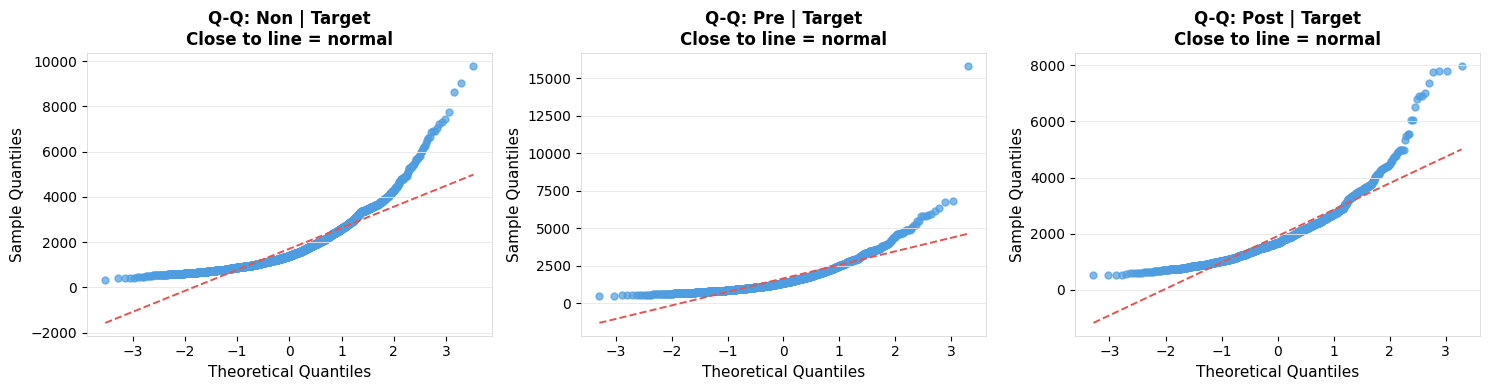

In [178]:
qq_plot_grid(cells_rt_1, ncols=3)

## 1.7 SAP 2.3 / 2.4 — RT Analysis

In [179]:
rt_analysis(df_both_labeled, "Experiment 1")


═══════════════════════════════════════════════════════
  Experiment 1: RT Analysis (SAP 2.3/2.4)
  N participants: 49
═══════════════════════════════════════════════════════
Shapiro-Wilk on cell means: W=0.8192, p=0.0000 → Non-normal → KW fallback

--- Kruskal-Wallis: Boundary Position ---
  Kruskal-Wallis  H=13.5293,  p=0.0012  [Boundary Position]

--- Bonferroni Pairwise Wilcoxon: Boundary Position ---
  Bonferroni Pairwise Wilcoxon [Boundary Position]


Comparison,U,p_raw,p_bonferroni,Significant
Non vs Pre,1317.000000,0.409800,1.000000,False
Non vs Post,810.000000,0.005600,0.016800,True
Pre vs Post,716.000000,0.000600,0.001800,True



--- Paired Wilcoxon: Trial Type (Target vs Lure) ---

--- Interaction Proxy: Boundary within Target ---
  Kruskal-Wallis  H=13.5293,  p=0.0012  [Target boundary]
  Bonferroni Pairwise Wilcoxon [Target boundary]


Comparison,U,p_raw,p_bonferroni,Significant
Non vs Pre,1317.000000,0.409800,1.000000,False
Non vs Post,810.000000,0.005600,0.016800,True
Pre vs Post,716.000000,0.000600,0.001800,True



--- Interaction Proxy: Boundary within Lure ---
  Skipped – fewer than 2 groups: Lure boundary
  Skipped – fewer than 2 groups: Lure boundary


## 1.8 RT Descriptives

In [180]:
summary_table(aggregate_rt(df_both_labeled),
              ["boundary_position","stimulus_type"],
              "mean_rt", "Exp 1: Mean RT per Participant per Cell (ms)")


───────────────────────────────────────────────────────
  Exp 1: Mean RT per Participant per Cell (ms)
───────────────────────────────────────────────────────


boundary_position,stimulus_type,n,Median,Mean,SD,IQR
Non,Target,49,1590.597000,1701.366000,446.542000,400.218000
Pre,Target,49,1571.540000,1658.992000,538.784000,480.478000
Post,Target,49,1819.529000,1916.114000,489.033000,439.615000


,boundary_position,stimulus_type,n,Median,Mean,SD,IQR
0,Non,Target,49,1590.5970,1701.3660,446.5420,400.2180
1,Pre,Target,49,1571.5400,1658.9920,538.7840,480.4780
2,Post,Target,49,1819.5290,1916.1140,489.0330,439.6150


## 1.9 SAP 3.1 — REC and LDI

,participant_id,REC,LDI
0,15,0.2870,0.1530
1,16,0.2930,0.2600
2,17,0.2270,0.2200
3,18,0.3070,0.1930
4,19,0.2070,0.1400
5,20,0.1600,0.2400
6,21,0.2470,0.1330
7,22,0.2600,0.1270
8,23,0.2070,0.2400
9,24,0.3470,0.1530



Group summary:
          REC    LDI
median 0.2600 0.1730
std    0.0540 0.0620


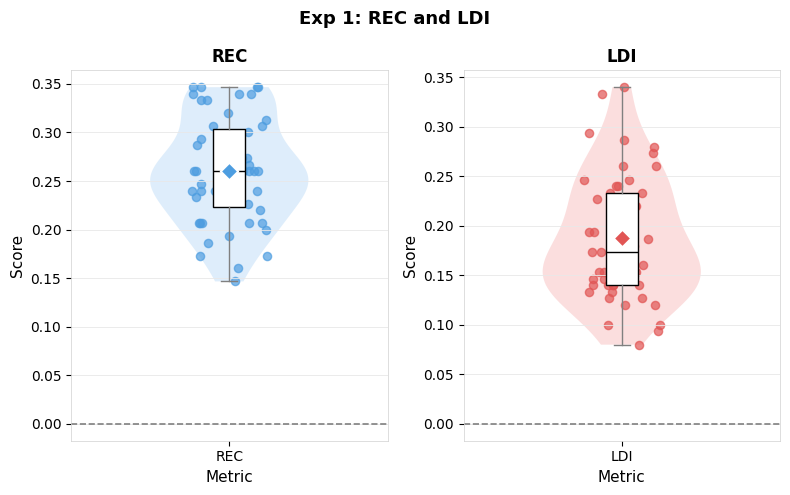

In [181]:
mst_1 = compute_mst_scores(df_both_test)
display(mst_1[["participant_id","REC","LDI"]].round(3))
print("\nGroup summary:")
print(mst_1[["REC","LDI"]].agg(["median","std"]).round(3))
rec_ldi_plot(mst_1, "Exp 1: REC and LDI")

## 1.10 SAP 3.2 / 4 — Memory Accuracy by Boundary Condition

In [182]:
bp_1 = compute_accuracy(df_both_test, df_both_task)
print(f"Participants: {bp_1.participant_id.nunique()}")
normality_table(
    [{"vals": grp.lure_CR.dropna().tolist(), "label": f"Lure CR | {bp}"}
     for bp, grp in bp_1.groupby("boundary_position", observed=True)],
    "Exp 1: Shapiro-Wilk — Lure CR")
normality_table(
    [{"vals": grp.target_hit.dropna().tolist(), "label": f"Target Hit | {bp}"}
     for bp, grp in bp_1.groupby("boundary_position", observed=True)],
    "Exp 1: Shapiro-Wilk — Target Hit")
summary_table(bp_1, "boundary_position", "lure_CR",    "Exp 1: Lure CR")
summary_table(bp_1, "boundary_position", "target_hit", "Exp 1: Target Hit")

Participants: 49

───────────────────────────────────────────────────────
  Exp 1: Shapiro-Wilk — Lure CR
───────────────────────────────────────────────────────


Condition,n,W,p,Normal
Lure CR | Non,49,nan,nan,Identical
Lure CR | Pre,49,nan,nan,Identical
Lure CR | Post,49,nan,nan,Identical



───────────────────────────────────────────────────────
  Exp 1: Shapiro-Wilk — Target Hit
───────────────────────────────────────────────────────


Condition,n,Normal
Target Hit | Non,49,Yes
Target Hit | Pre,49,Yes
Target Hit | Post,49,Yes



───────────────────────────────────────────────────────
  Exp 1: Lure CR
───────────────────────────────────────────────────────


boundary_position,n,Median,Mean,SD,IQR
Non,49,0.000000,0.000000,0.000000,0.000000
Pre,49,0.000000,0.000000,0.000000,0.000000
Post,49,0.000000,0.000000,0.000000,0.000000



───────────────────────────────────────────────────────
  Exp 1: Target Hit
───────────────────────────────────────────────────────


boundary_position,n,Median,Mean,SD,IQR
Non,49,0.536000,0.520000,0.110000,0.165000
Pre,49,0.586000,0.593000,0.134000,0.171000
Post,49,0.538000,0.548000,0.152000,0.197000


,boundary_position,n,Median,Mean,SD,IQR
0,Non,49,0.5360,0.5200,0.1100,0.1650
1,Pre,49,0.5860,0.5930,0.1340,0.1710
2,Post,49,0.5380,0.5480,0.1520,0.1970


## 1.11 Accuracy Plots

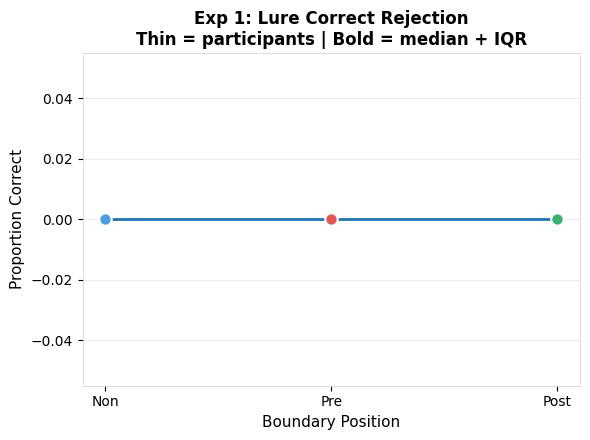

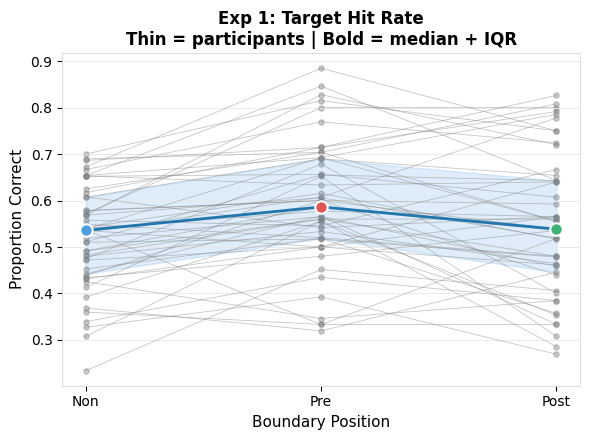

In [183]:
spaghetti_plot(bp_1, "boundary_position", "lure_CR",
               title="Exp 1: Lure Correct Rejection",
               subtitle="Thin = participants | Bold = median + IQR",
               x_lab="Boundary Position", y_lab="Proportion Correct")
spaghetti_plot(bp_1, "boundary_position", "target_hit",
               title="Exp 1: Target Hit Rate",
               subtitle="Thin = participants | Bold = median + IQR",
               x_lab="Boundary Position", y_lab="Proportion Correct")

## 1.12 SAP 5 / 6 — RM Analysis + Post-Hoc

In [ ]:


rm_analysis(bp_1, "lure_CR", label="Exp 1: Lure CR")
rm_analysis(bp_1, "target_hit", label="Exp 1: Target Hit")


───────────────────────────────────────────────────────
  Exp 1: Lure CR: RM Analysis — DV: lure_CR
───────────────────────────────────────────────────────
  Participants included: 49  |  Dropped: 0
  Friedman: stat=nan, p=nan

  Bonferroni pairwise Wilcoxon (SAP 6):


Comparison,W,p_raw,p_bonferroni,Significant
Non vs Pre,0.000000,nan,nan,False
Non vs Post,0.000000,nan,nan,False
Pre vs Post,0.000000,nan,nan,False



───────────────────────────────────────────────────────
  Exp 1: Target Hit: RM Analysis — DV: target_hit
───────────────────────────────────────────────────────
  Participants included: 49  |  Dropped: 0
  Shapiro-Wilk: W=0.9914, p=0.5119 → Normal → RM-ANOVA


,Source,SS,DF,MS,F,p_unc,ng2,eps
0,boundary_position,0.1321,2,0.0660,12.2522,0.0000,0.0492,0.9167
1,Error,0.5175,96,0.0054,NaN,NaN,NaN,NaN



  Bonferroni pairwise t-tests (SAP 6):


Comparison,t,p_raw,p_bonferroni,Significant
Non vs Pre,-2.944000,0.004100,0.012300,True
Non vs Post,-1.058000,0.292800,0.878400,False
Pre vs Post,1.535000,0.128200,0.384600,False


,participant_id,boundary_position,target_hit
0,15,Non,0.5319
1,15,Pre,0.6071
2,15,Post,0.7778
3,16,Non,0.6250
4,16,Pre,0.7037
...,...,...,...
142,66,Pre,0.8000
143,66,Post,0.8000
144,67,Non,0.6897
145,67,Pre,0.7037


## 1.13 SAP 7 / 7.1 — Difference Scores

In [ ]:
diff_1 = compute_diff_scores(bp_1)
display(diff_1[["participant_id","lure_pre_diff","lure_post_diff",
                "target_pre_diff","target_post_diff"]].round(3))
one_sample_test_adaptive(diff_1.lure_pre_diff,    "Lure CR: Pre - Non (Exp 1)")
one_sample_test_adaptive(diff_1.lure_post_diff,   "Lure CR: Post - Non (Exp 1)")
one_sample_test_adaptive(diff_1.target_pre_diff,  "Target Hit: Pre - Non (Exp 1)")
one_sample_test_adaptive(diff_1.target_post_diff, "Target Hit: Post - Non (Exp 1)")

,participant_id,lure_pre_diff,lure_post_diff,target_pre_diff,target_post_diff
0,15,0.0000,0.0000,0.0750,0.2460
1,16,0.0000,0.0000,0.0790,-0.0690
2,17,0.0000,0.0000,0.0460,0.1020
3,18,0.0000,0.0000,0.0210,0.0140
4,19,0.0000,0.0000,0.0690,0.0300
5,20,0.0000,0.0000,0.2180,0.1720
6,22,0.0000,0.0000,-0.0290,-0.0690
7,24,0.0000,0.0000,0.0970,0.2090
8,25,0.0000,0.0000,-0.0660,-0.0430
9,26,0.0000,0.0000,0.2390,-0.1050



--- Lure CR: Pre - Non (Exp 1) ---
  SW: W=1.0000, p=1.0000 → Normal → one-sample t
  t=nan, p=nan, mean=0.0000

--- Lure CR: Post - Non (Exp 1) ---
  SW: W=1.0000, p=1.0000 → Normal → one-sample t
  t=nan, p=nan, mean=0.0000

--- Target Hit: Pre - Non (Exp 1) ---
  SW: W=0.9725, p=0.3046 → Normal → one-sample t
  t=5.3690, p=0.0000, mean=0.0728

--- Target Hit: Post - Non (Exp 1) ---
  SW: W=0.9433, p=0.0199 → Non-normal → Wilcoxon signed-rank
  W=455.0000, p=0.1190, median=0.0136


## 1.14 Difference Score Plot

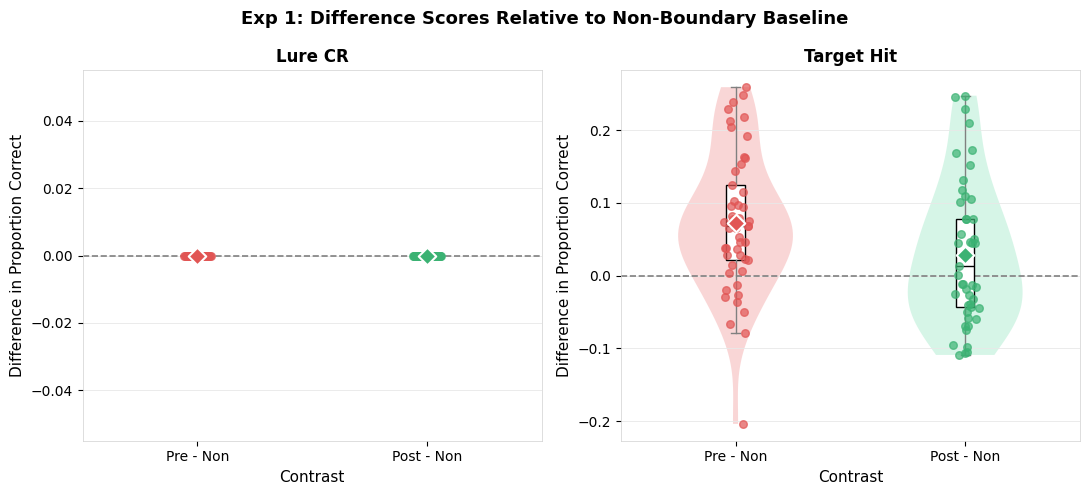

In [ ]:
diff_score_plot(diff_1, "Exp 1: Difference Scores Relative to Non-Boundary Baseline")

## 1.15 SAP 8 — Pre vs Post Paired Test

In [ ]:
paired_test_adaptive(bp_1, "lure_CR",    "Exp 1: Lure CR")
paired_test_adaptive(bp_1, "target_hit", "Exp 1: Target Hit")


--- Exp 1: Lure CR: Paired Pre vs Post (SAP 8) ---
  Complete pairs: 49
  SW on diffs: W=1.0000, p=1.0000 → Normal → paired t
  SW on diffs: W=1.0000, p=1.0000 → Normal → paired t
  t=nan, p=nan

--- Exp 1: Target Hit: Paired Pre vs Post (SAP 8) ---
  Complete pairs: 49
  SW on diffs: W=0.9839, p=0.7357 → Normal → paired t
  SW on diffs: W=0.9839, p=0.7357 → Normal → paired t
  t=2.6264, p=0.0115


## 1.16 SAP 9 — Linear Mixed-Effects Model

In [ ]:
run_lme_trial(df_both_labeled, "Exp 1")


═══════════════════════════════════════════════════════
  Exp 1: LME Models (SAP 9)
═══════════════════════════════════════════════════════

--- Lure Correct Rejection ---
  Too few participants.

--- Target Hit Rate ---
                                Mixed Linear Model Regression Results
Model:                           MixedLM                Dependent Variable:                target_hit
No. Observations:                6059                   Method:                            REML      
No. Groups:                      49                     Scale:                             0.2366    
Min. group size:                 107                    Log-Likelihood:                    inf       
Max. group size:                 402                    Converged:                         Yes       
Mean group size:                 123.7                                                               
------------------------------------------------------------------------------------------------

## 1.17 SAP 10 — Lure Similarity Bin Analysis

In [ ]:
lure_bin_analysis(
    df_both_test,
    df_both_task,
    bins_obj=bins_obj_1,
    bins_scenes=bins_scenes_1,
    exp_label="Exp 1"
)


═══════════════════════════════════════════════════════
  Exp 1: Lure Similarity Bin Analysis (SAP 10)
═══════════════════════════════════════════════════════



ValueError: Cannot set a DataFrame with multiple columns to the single column sim_bin

---
# Experiment 2: Item Only
**Folder:** `../item_only/item_only_data/`  
**Bin files:** `../item_only/Set6 bins.txt` + `../item_only/SetScC bins.txt`  
**Scenes mapping:** `../item_only/scenes_mapping.txt`

## Exp 2 — Load Bin & Scenes Mapping Files

In [190]:
bins_obj_2      = load_bin_file(data_path("item_only", "Set6 bins.txt"))
bins_scenes_2   = load_bin_file(data_path("item_only", "SetScC bins.txt"))
scenes_mapping  = load_scenes_mapping(data_path("item_only", "scenes_mapping.txt"))
print(f"Set6 bins: {len(bins_obj_2)} | SetScC bins: {len(bins_scenes_2)} | Scenes mapping: {len(scenes_mapping)}")

Set6 bins: 192 | SetScC bins: 192 | Scenes mapping: 113


## 2.1 Load Task & Test Data

In [191]:
df_item_task, df_item_test = load_experiment(
    task_pattern=data_path("item_only","item_only_data","*_MST_task_*.csv"),
    test_pattern=data_path("item_only","item_only_data","*_MST_test_*.csv"),
    exp_label="Experiment 2 (Item-Only)"
)

Experiment 2 (Item-Only)  —  Task files: 56  |  Test files: 56
  Task participants: 53
  Test participants: 53


## 2.2 Participant Cross-Check

In [192]:
in_task_only = set(df_item_task.participant_id.unique()) - set(df_item_test.participant_id.unique())
in_test_only = set(df_item_test.participant_id.unique()) - set(df_item_task.participant_id.unique())
print(f"In task only: {sorted(in_task_only)}")
print(f"In test only: {sorted(in_test_only)}")

In task only: []
In test only: []


## 2.3 Join Task and Test

In [193]:
df_item_labeled = join_task_test(df_item_task, df_item_test)
print(f"Rows: {len(df_item_labeled)}  |  Participants: {df_item_labeled.participant_id.nunique()}")

Rows: 6995  |  Participants: 53


## 2.4 SAP 2.2 — Normality: Encoding RT

In [194]:
cells_rt_2 = [
    {"vals": grp["rt"].dropna().tolist(), "label": f"{bp} | {st}"}
    for (bp, st), grp in df_item_labeled.groupby(["boundary_position","stimulus_type"], observed=True)
]
normality_table(cells_rt_2, "Exp 2: Shapiro-Wilk — Encoding RT by Cell")


───────────────────────────────────────────────────────
  Exp 2: Shapiro-Wilk — Encoding RT by Cell
───────────────────────────────────────────────────────


Condition,n,Normal
Non | Target,3874,No
Pre | Target,1558,No
Post | Target,1563,No


,Condition,n,Normal
0,Non | Target,3874,No
1,Pre | Target,1558,No
2,Post | Target,1563,No


## 2.5 Q-Q Plots

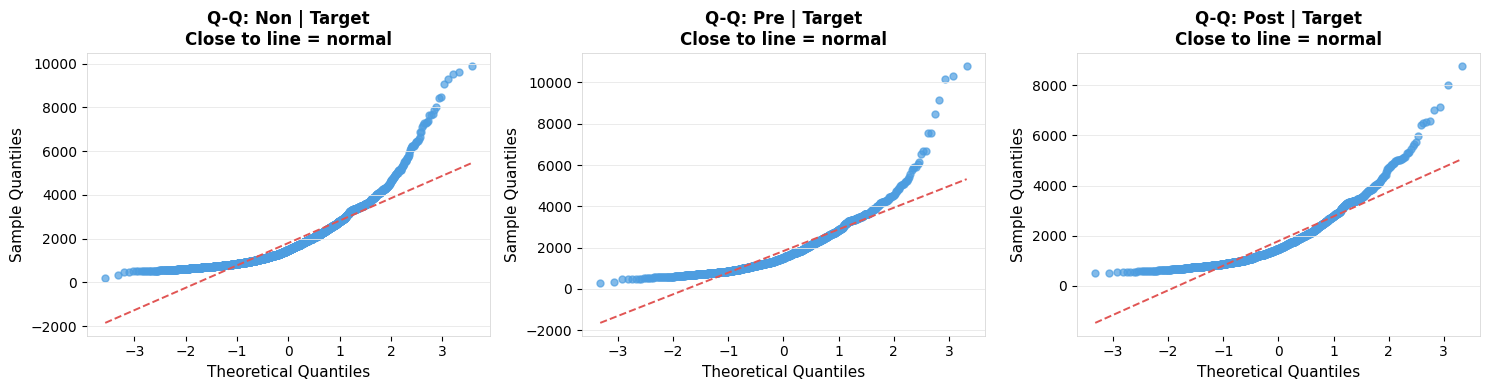

In [195]:
qq_plot_grid(cells_rt_2, ncols=3)

## 2.6 SAP 2.3 / 2.4 — RT Analysis

In [196]:
rt_analysis(df_item_labeled, "Experiment 2")


═══════════════════════════════════════════════════════
  Experiment 2: RT Analysis (SAP 2.3/2.4)
  N participants: 53
═══════════════════════════════════════════════════════
Shapiro-Wilk on cell means: W=0.8760, p=0.0000 → Non-normal → KW fallback

--- Kruskal-Wallis: Boundary Position ---
  Kruskal-Wallis  H=0.2443,  p=0.8850  [Boundary Position]

--- Bonferroni Pairwise Wilcoxon: Boundary Position ---
  Bonferroni Pairwise Wilcoxon [Boundary Position]


Comparison,U,p_raw,p_bonferroni,Significant
Non vs Pre,1340.000000,0.685900,1.000000,False
Non vs Post,1409.000000,0.979800,1.000000,False
Pre vs Post,1475.000000,0.658300,1.000000,False



--- Paired Wilcoxon: Trial Type (Target vs Lure) ---

--- Interaction Proxy: Boundary within Target ---
  Kruskal-Wallis  H=0.2443,  p=0.8850  [Target boundary]
  Bonferroni Pairwise Wilcoxon [Target boundary]


Comparison,U,p_raw,p_bonferroni,Significant
Non vs Pre,1340.000000,0.685900,1.000000,False
Non vs Post,1409.000000,0.979800,1.000000,False
Pre vs Post,1475.000000,0.658300,1.000000,False



--- Interaction Proxy: Boundary within Lure ---
  Skipped – fewer than 2 groups: Lure boundary
  Skipped – fewer than 2 groups: Lure boundary


## 2.7 RT Descriptives and Plot


───────────────────────────────────────────────────────
  Exp 2: Mean RT per Participant per Cell (ms)
───────────────────────────────────────────────────────


boundary_position,stimulus_type,n,Median,Mean,SD,IQR
Non,Target,53,1599.575000,1789.263000,564.719000,632.391000
Pre,Target,53,1718.089000,1818.994000,586.069000,503.101000
Post,Target,53,1638.829000,1777.478000,551.466000,512.995000


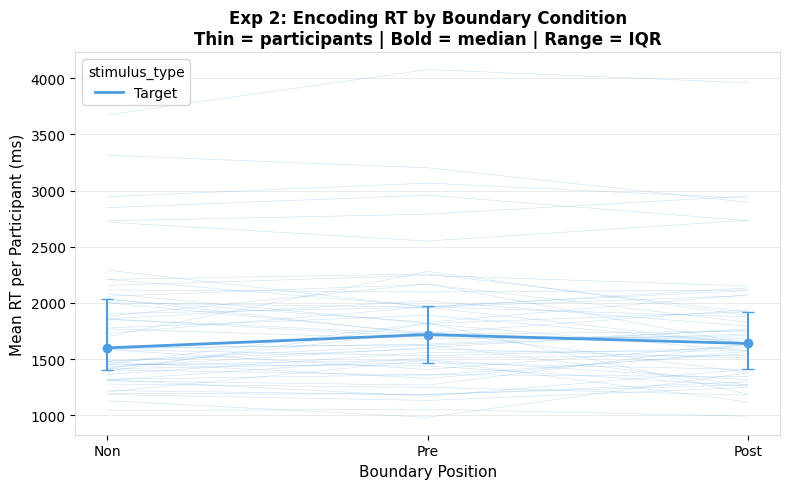

In [197]:
summary_table(aggregate_rt(df_item_labeled),
              ["boundary_position","stimulus_type"],
              "mean_rt", "Exp 2: Mean RT per Participant per Cell (ms)")
spaghetti_grouped(
    aggregate_rt(df_item_labeled),
    x_var="boundary_position", y_var="mean_rt", group_var="stimulus_type",
    title="Exp 2: Encoding RT by Boundary Condition",
    subtitle="Thin = participants | Bold = median | Range = IQR",
    x_lab="Boundary Position", y_lab="Mean RT per Participant (ms)"
)

## 2.8 SAP 3.1 — REC and LDI

,participant_id,REC,LDI
0,1,0.2800,0.2270
1,10,0.3000,0.1670
2,11,0.3070,0.2800
3,12,0.1470,0.2130
4,13,0.2670,0.2270
5,14,0.1930,0.1200
6,15,0.2930,0.3000
7,16,0.3600,0.1870
8,17,0.3100,0.1730
9,18,0.3000,0.2100


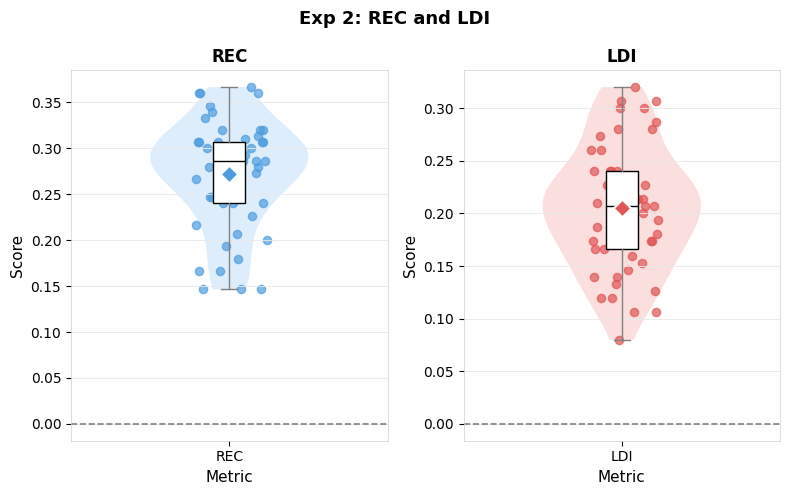

In [198]:
mst_2 = compute_mst_scores(df_item_test)
display(mst_2[["participant_id","REC","LDI"]].round(3))
rec_ldi_plot(mst_2, "Exp 2: REC and LDI")

## 2.9 SAP 3.2 / 4 — Memory Accuracy

In [199]:
bp_2 = compute_accuracy(df_item_test, df_item_task)
print(f"Participants: {bp_2.participant_id.nunique()}")
summary_table(bp_2, "boundary_position", "lure_CR",    "Exp 2: Lure CR")
summary_table(bp_2, "boundary_position", "target_hit", "Exp 2: Target Hit")

Participants: 53

───────────────────────────────────────────────────────
  Exp 2: Lure CR
───────────────────────────────────────────────────────


boundary_position,n,Median,Mean,SD,IQR
Non,53,0.000000,0.000000,0.000000,0.000000
Pre,53,0.000000,0.000000,0.000000,0.000000
Post,53,0.000000,0.000000,0.000000,0.000000



───────────────────────────────────────────────────────
  Exp 2: Target Hit
───────────────────────────────────────────────────────


boundary_position,n,Median,Mean,SD,IQR
Non,53,0.564000,0.542000,0.115000,0.133000
Pre,53,0.613000,0.599000,0.149000,0.157000
Post,53,0.625000,0.618000,0.154000,0.184000


,boundary_position,n,Median,Mean,SD,IQR
0,Non,53,0.5640,0.5420,0.1150,0.1330
1,Pre,53,0.6130,0.5990,0.1490,0.1570
2,Post,53,0.6250,0.6180,0.1540,0.1840


## 2.10 Accuracy Plots

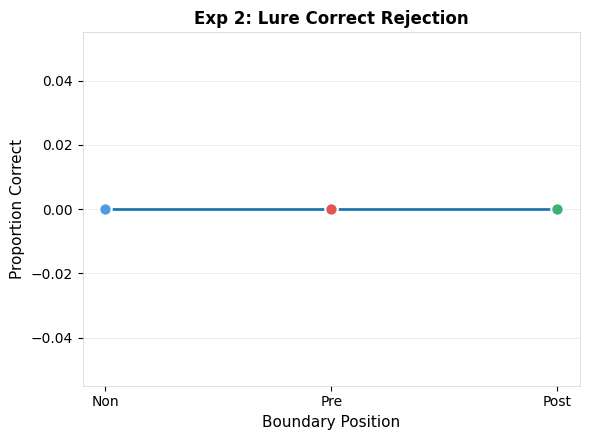

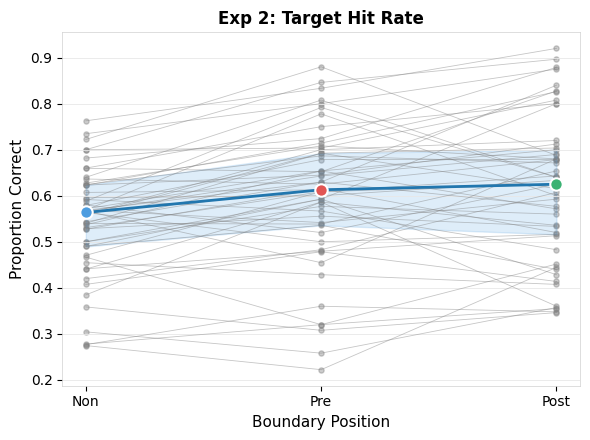

In [200]:
spaghetti_plot(bp_2, "boundary_position", "lure_CR",
               title="Exp 2: Lure Correct Rejection", x_lab="Boundary Position", y_lab="Proportion Correct")
spaghetti_plot(bp_2, "boundary_position", "target_hit",
               title="Exp 2: Target Hit Rate", x_lab="Boundary Position", y_lab="Proportion Correct")

## 2.11 SAP 5 / 6 — RM Analysis

In [201]:
rm_analysis(bp_2, "lure_CR",    label="Exp 2: Lure CR")
rm_analysis(bp_2, "target_hit", label="Exp 2: Target Hit")


───────────────────────────────────────────────────────
  Exp 2: Lure CR: RM Analysis — DV: lure_CR
───────────────────────────────────────────────────────
  Participants included: 53  |  Dropped: 0
  Friedman: stat=nan, p=nan

  Bonferroni pairwise Wilcoxon (SAP 6):


Comparison,W,p_raw,p_bonferroni,Significant
Non vs Pre,0.000000,nan,nan,False
Non vs Post,0.000000,nan,nan,False
Pre vs Post,0.000000,nan,nan,False



───────────────────────────────────────────────────────
  Exp 2: Target Hit: RM Analysis — DV: target_hit
───────────────────────────────────────────────────────
  Participants included: 53  |  Dropped: 0
  Shapiro-Wilk: W=0.9876, p=0.1736 → Normal → RM-ANOVA


,Source,SS,DF,MS,F,p_unc,p_GG_corr,ng2,eps,sphericity,W_spher,p_spher
0,boundary_position,0.1646,2,0.0823,19.4279,0.0000,0.0000,0.0506,0.8749,False,0.8570,0.0196
1,Error,0.4406,104,0.0042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



  Bonferroni pairwise t-tests (SAP 6):


Comparison,t,p_raw,p_bonferroni,Significant
Non vs Pre,-2.212000,0.029200,0.087600,False
Non vs Post,-2.855000,0.005200,0.015600,True
Pre vs Post,-0.618000,0.538000,1.000000,False


,participant_id,boundary_position,target_hit
0,1,Non,0.5667
1,1,Pre,0.4545
2,1,Post,0.6800
3,10,Non,0.5714
4,10,Pre,0.6538
...,...,...,...
154,8,Pre,0.7143
155,8,Post,0.8261
156,9,Non,0.4902
157,9,Pre,0.5357


## 2.12 SAP 7 / 7.1 — Difference Scores

,participant_id,lure_pre_diff,lure_post_diff,target_pre_diff,target_post_diff
0,1,0.0000,0.0000,-0.1120,0.1130
1,10,0.0000,0.0000,0.0820,0.1290
2,11,0.0000,0.0000,0.1400,0.1600
3,12,0.0000,0.0000,0.0830,0.0710
4,13,0.0000,0.0000,0.0860,0.0330
5,14,0.0000,0.0000,0.0710,0.0060
6,15,0.0000,0.0000,0.0610,0.2720
7,16,0.0000,0.0000,0.1460,0.1970
8,17,0.0000,0.0000,0.0220,0.0890
9,18,0.0000,0.0000,0.0620,0.0470



--- Lure CR: Pre - Non (Exp 2) ---
  SW: W=1.0000, p=1.0000 → Normal → one-sample t
  t=nan, p=nan, mean=0.0000

--- Lure CR: Post - Non (Exp 2) ---
  SW: W=1.0000, p=1.0000 → Normal → one-sample t
  t=nan, p=nan, mean=0.0000

--- Target Hit: Pre - Non (Exp 2) ---
  SW: W=0.9817, p=0.5878 → Normal → one-sample t
  t=5.2715, p=0.0000, mean=0.0573

--- Target Hit: Post - Non (Exp 2) ---
  SW: W=0.9885, p=0.8887 → Normal → one-sample t
  t=6.3175, p=0.0000, mean=0.0755


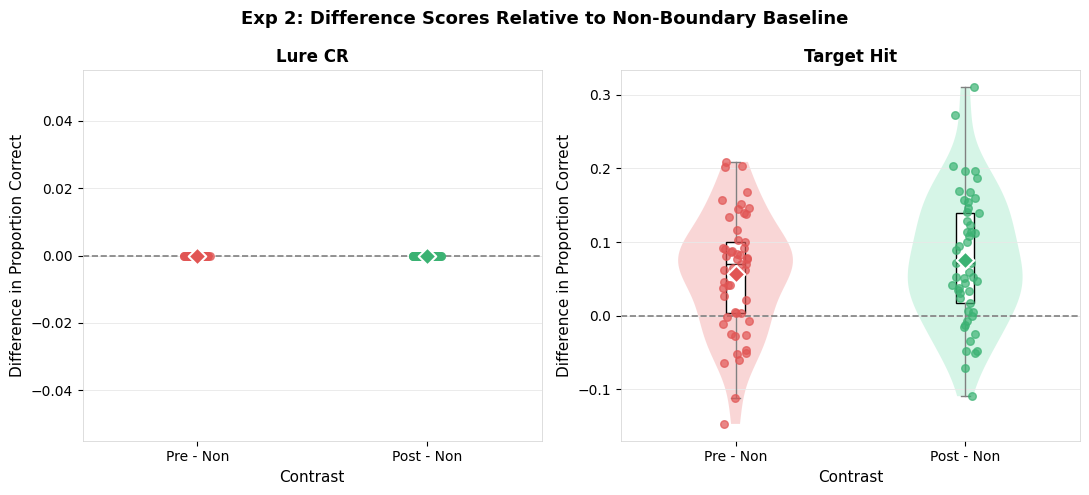

In [202]:
diff_2 = compute_diff_scores(bp_2)
display(diff_2[["participant_id","lure_pre_diff","lure_post_diff",
                "target_pre_diff","target_post_diff"]].round(3))
one_sample_test_adaptive(diff_2.lure_pre_diff,    "Lure CR: Pre - Non (Exp 2)")
one_sample_test_adaptive(diff_2.lure_post_diff,   "Lure CR: Post - Non (Exp 2)")
one_sample_test_adaptive(diff_2.target_pre_diff,  "Target Hit: Pre - Non (Exp 2)")
one_sample_test_adaptive(diff_2.target_post_diff, "Target Hit: Post - Non (Exp 2)")
diff_score_plot(diff_2, "Exp 2: Difference Scores Relative to Non-Boundary Baseline")

## 2.13 SAP 8 — Pre vs Post

In [203]:
paired_test_adaptive(bp_2, "lure_CR",    "Exp 2: Lure CR")
paired_test_adaptive(bp_2, "target_hit", "Exp 2: Target Hit")


--- Exp 2: Lure CR: Paired Pre vs Post (SAP 8) ---
  Complete pairs: 53
  SW on diffs: W=1.0000, p=1.0000 → Normal → paired t
  SW on diffs: W=1.0000, p=1.0000 → Normal → paired t
  t=nan, p=nan

--- Exp 2: Target Hit: Paired Pre vs Post (SAP 8) ---
  Complete pairs: 53
  SW on diffs: W=0.9792, p=0.4803 → Normal → paired t
  SW on diffs: W=0.9792, p=0.4803 → Normal → paired t
  t=-1.2331, p=0.2231


## 2.14 SAP 9 — LME Model

In [204]:
run_lme_trial(df_item_labeled, "Exp 2")


═══════════════════════════════════════════════════════
  Exp 2: LME Models (SAP 9)
═══════════════════════════════════════════════════════

--- Lure Correct Rejection ---
  Too few participants.

--- Target Hit Rate ---
                         Mixed Linear Model Regression Results
Model:                       MixedLM           Dependent Variable:           target_hit
No. Observations:            6995              Method:                       REML      
No. Groups:                  53                Scale:                        0.2336    
Min. group size:             103               Log-Likelihood:               inf       
Max. group size:             383               Converged:                    Yes       
Mean group size:             132.0                                                     
---------------------------------------------------------------------------------------
                                               Coef. Std.Err.   z   P>|z| [0.025 0.975]
-----------

## 2.15 SAP 10 — Lure Similarity Bin Analysis

In [205]:
lure_bin_analysis(df_item_test, df_item_task,
                   bins_obj=bins_obj_2,
                   bins_scenes=bins_scenes_2,
                   exp_label="Exp 2")


═══════════════════════════════════════════════════════
  Exp 2: Lure Similarity Bin Analysis (SAP 10)
═══════════════════════════════════════════════════════



ValueError: Cannot set a DataFrame with multiple columns to the single column sim_bin

---
# Experiment 3: Task Only
**Folder:** `../task_only/task_only_data/`  
**Bin file:** `../task_only/Set6 bins_ob.txt` (Objects extended, up to 384 items — no Scenes bin file needed)

## Exp 3 — Load Bin File

In [206]:
bins_obj_3_extended = load_bin_file(data_path("task_only", "Set6 bins_ob.txt"))
print(f"Set6_bins_ob loaded: {len(bins_obj_3_extended)} items  (covers Object numbers 1–384)")

Set6_bins_ob loaded: 384 items  (covers Object numbers 1–384)


## 3.1 Load Task & Test Data

In [212]:
df_task_task, df_task_test = load_experiment(
    task_pattern=data_path("task_only","task_only_data","task*.csv"),
    test_pattern=data_path("task_only","task_only_data","test*.csv"),
    exp_label="Experiment 3 (Task-Only)"
)

Experiment 3 (Task-Only)  —  Task files: 0  |  Test files: 0
  ⚠ No task files found at: /home/user/Desktop/SEMESTER6/BRSM/Project/BRSM-MST/MST_Data (1)/task_only/task_only_data/task*.csv
  ⚠ No test files found at: /home/user/Desktop/SEMESTER6/BRSM/Project/BRSM-MST/MST_Data (1)/task_only/task_only_data/test*.csv


## 3.2 Participant Cross-Check

In [213]:
in_task_only = set(df_task_task.participant_id.unique()) - set(df_task_test.participant_id.unique())
in_test_only = set(df_task_test.participant_id.unique()) - set(df_task_task.participant_id.unique())
print(f"In task only: {sorted(in_task_only)}")
print(f"In test only: {sorted(in_test_only)}")

AttributeError: 'DataFrame' object has no attribute 'participant_id'

## 3.3 Join Task and Test

In [210]:
df_task_labeled = join_task_test(df_task_task, df_task_test)
print(f"Rows: {len(df_task_labeled)}  |  Participants: {df_task_labeled.participant_id.nunique()}")

AttributeError: 'DataFrame' object has no attribute 'stimulus_type'

## 3.4 SAP 2.2 — Normality: Encoding RT

In [211]:
cells_rt_3 = [
    {"vals": grp["rt"].dropna().tolist(), "label": f"{bp} | {st}"}
    for (bp, st), grp in df_task_labeled.groupby(["boundary_position","stimulus_type"], observed=True)
]
normality_table(cells_rt_3, "Exp 3: Shapiro-Wilk — Encoding RT by Cell")

NameError: name 'df_task_labeled' is not defined

## 3.5 Q-Q Plots

In [ ]:
qq_plot_grid(cells_rt_3, ncols=3)

## 3.6 SAP 2.3 / 2.4 — RT Analysis

In [ ]:
rt_analysis(df_task_labeled, "Experiment 3")

## 3.7 RT Descriptives and Plot

In [ ]:
summary_table(aggregate_rt(df_task_labeled),
              ["boundary_position","stimulus_type"],
              "mean_rt", "Exp 3: Mean RT per Participant per Cell (ms)")
spaghetti_grouped(
    aggregate_rt(df_task_labeled),
    x_var="boundary_position", y_var="mean_rt", group_var="stimulus_type",
    title="Exp 3: Encoding RT by Boundary Condition",
    subtitle="Thin = participants | Bold = median | Range = IQR",
    x_lab="Boundary Position", y_lab="Mean RT per Participant (ms)"
)

## 3.8 SAP 3.1 — REC and LDI

In [ ]:
mst_3 = compute_mst_scores(df_task_test)
display(mst_3[["participant_id","REC","LDI"]].round(3))
rec_ldi_plot(mst_3, "Exp 3: REC and LDI")

## 3.9 SAP 3.2 / 4 — Memory Accuracy

In [ ]:
bp_3 = compute_accuracy(df_task_test, df_task_task)
print(f"Participants: {bp_3.participant_id.nunique()}")
summary_table(bp_3, "boundary_position", "lure_CR",    "Exp 3: Lure CR")
summary_table(bp_3, "boundary_position", "target_hit", "Exp 3: Target Hit")

## 3.10 Accuracy Plots

In [ ]:
spaghetti_plot(bp_3, "boundary_position", "lure_CR",
               title="Exp 3: Lure Correct Rejection", x_lab="Boundary Position", y_lab="Proportion Correct")
spaghetti_plot(bp_3, "boundary_position", "target_hit",
               title="Exp 3: Target Hit Rate", x_lab="Boundary Position", y_lab="Proportion Correct")

## 3.11 SAP 5 / 6 — RM Analysis

In [ ]:
rm_analysis(bp_3, "lure_CR",    label="Exp 3: Lure CR")
rm_analysis(bp_3, "target_hit", label="Exp 3: Target Hit")

## 3.12 SAP 7 / 7.1 — Difference Scores

In [ ]:
diff_3 = compute_diff_scores(bp_3)
display(diff_3[["participant_id","lure_pre_diff","lure_post_diff",
                "target_pre_diff","target_post_diff"]].round(3))
one_sample_test_adaptive(diff_3.lure_pre_diff,    "Lure CR: Pre - Non (Exp 3)")
one_sample_test_adaptive(diff_3.lure_post_diff,   "Lure CR: Post - Non (Exp 3)")
one_sample_test_adaptive(diff_3.target_pre_diff,  "Target Hit: Pre - Non (Exp 3)")
one_sample_test_adaptive(diff_3.target_post_diff, "Target Hit: Post - Non (Exp 3)")
diff_score_plot(diff_3, "Exp 3: Difference Scores Relative to Non-Boundary Baseline")

## 3.13 SAP 8 — Pre vs Post

In [ ]:
paired_test_adaptive(bp_3, "lure_CR",    "Exp 3: Lure CR")
paired_test_adaptive(bp_3, "target_hit", "Exp 3: Target Hit")

## 3.14 SAP 9 — LME Model

In [ ]:
run_lme_trial(df_task_labeled, "Exp 3")

## 3.15 SAP 10 — Lure Similarity Bin Analysis

In [ ]:
# Task-only uses extended bin file (384 items, Objects only — no Scenes in this experiment)
lure_bin_analysis(df_task_test, df_task_task,
                   bins_obj=bins_obj_3_extended,
                   bins_scenes={},           # no Scenes in task_only
                   bins_obj_extended=bins_obj_3_extended,
                   exp_label="Exp 3")